# ノイズ除去で、異常検知は良くなるか？ — 第2回の実験を読む

[Zenn第1回](https://zenn.dev/kasahart/articles/kasahart-20260919-dcase2026-asd-01)の続きです。記事では、**同じ検知器に渡す音だけを変えたとき、成績がどう変わるか**を比較しました。このNotebookでは結果の表を読み、合成音の図で2種類の引き算の違いを確かめます。

**GitHubで読むだけなら、実行やインストールは不要です。** 保存済みの表と図を、そのまま下へ読んでください。音声・重みのダウンロードも不要です。ローカルでの手動試聴は3節で案内します。GitHub上では試聴ボタンを使いません。

## 1. 4条件で何を変えたか

| 記号 | 記事での呼び方 | 検知器に渡す音 |
|---|---|---|
| B0 | 近いマイクのみ | 近いマイクの録音をそのまま使う。比較の基準 |
| B1 | 遠いマイクのみ | 遠いマイクの録音をそのまま使う |
| W1 | 線形減算（複素減算） | 遠い側の大きさと位相を調整して、近い側から引く |
| SS | スペクトル減算（式1） | 周波数ごとの大きさを引き、近い側の位相で波形へ戻す |

どの条件もBEATs・RDP・BEAM・VarMinの設定は共通です。**正常音の比較基準も、それぞれの条件で作り直します。**

*次のセルは表示の準備コードです。読むだけなら飛ばして、結果の表へ進んでください。*

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import wandas as wd
from IPython.display import display
from asd_min.notebook import frames, source_frames, show_sources, show
ROOT = Path.cwd() if (Path.cwd()/"results").is_dir() else Path.cwd().parent
assert (ROOT/"results/02-summary.csv").is_file()
assert wd.__version__ == "0.8.0"
ENABLE_AUDIO = False  # Trueで手動再生controlを生成。自動再生しない。
plt.rcParams.update({"font.size": 11, "figure.dpi": 100})
from asd_min.waveform import SYNTHETIC_PARAMETERS

## 2. 結果の読み方 — W1は上がり、SSは総合では上がらなかった

次の表の「総合スコア」は記事の検証スコアと同じものです。高いほど良く、「B0との差」は近いマイクのみを基準にした**ポイント差**です。

In [2]:
summary = pd.read_csv(ROOT/"results/02-summary.csv").set_index("condition").reindex(["b0","b1","w1","ss"])
CONDITION_NAMES = {"b0":"B0：近いマイク", "b1":"B1：遠いマイク", "w1":"W1：線形減算", "ss":"SS：スペクトル減算"}
totals = summary["official_score"]*100
reading_table = pd.DataFrame({"条件":[CONDITION_NAMES[c] for c in summary.index],
                              "総合スコア":totals.to_numpy(),
                              "B0との差（ポイント）":(totals-totals.loc["b0"]).to_numpy()})
display(reading_table.round(3))

,条件,総合スコア,B0との差（ポイント）
0,B0：近いマイク,62.841,0.000
1,B1：遠いマイク,58.362,-4.479
2,W1：線形減算,66.835,3.994
3,SS：スペクトル減算,62.325,-0.516


**この比較では、W1はB0より高く、SSは低い結果です。** 遠いマイクを使えば必ず改善するわけではなく、使い方で結果が変わりました。

### 機種ごとの結果も見る

pAUCは、正常音への誤警報を少なく抑えた範囲で、異常を見分ける成績です。表と棒グラフはpAUCを100倍し、0〜100で示しています。グラフの機種名は配布データの英語名です。日本語との対応は表に示します。

condition,B0：近いマイク,B1：遠いマイク,W1：線形減算,SS：スペクトル減算
machine,,,,
集じん機（BlowerDustCollector）,72.000,59.842,73.158,73.474
研磨機（Sander）,51.947,49.263,55.947,52.368
ミシン（SewingMachine）,66.000,59.158,67.105,64.684
電動歯ブラシ（ToothBrush）,50.158,51.368,53.211,49.632
小型ドローン（ToyDrone）,57.842,57.105,62.316,57.579


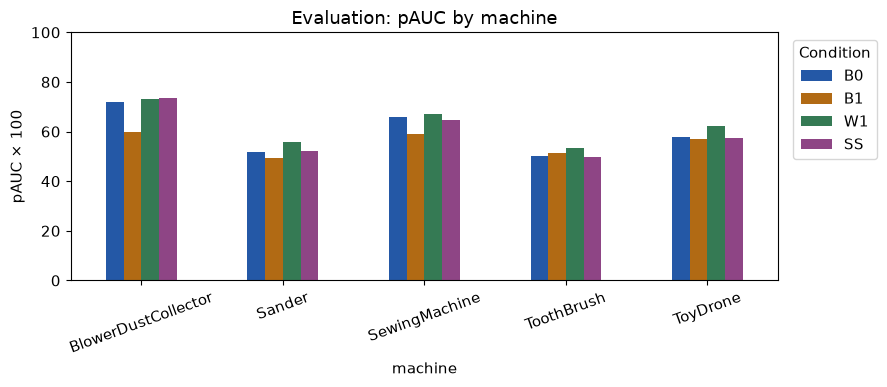

In [3]:
by_machine = pd.read_csv(ROOT/"results/02-by-machine.csv")
pauc = by_machine.pivot(index="machine", columns="condition", values="pauc").reindex(columns=["b0","b1","w1","ss"])*100
MACHINE_NAMES = {"BlowerDustCollector":"集じん機（BlowerDustCollector）", "Sander":"研磨機（Sander）",
                 "SewingMachine":"ミシン（SewingMachine）", "ToothBrush":"電動歯ブラシ（ToothBrush）", "ToyDrone":"小型ドローン（ToyDrone）"}
display(pauc.rename(index=MACHINE_NAMES, columns=CONDITION_NAMES).round(3))
ax=pauc.rename(columns={c:c.upper() for c in pauc.columns}).plot.bar(figsize=(9,4), rot=20,
    color=["#2458a6","#b16a14","#357a54","#8e4585"])
ax.set(title="Evaluation: pAUC by machine", ylabel="pAUC × 100", ylim=(0,100))
ax.legend(title="Condition", loc="upper left", bbox_to_anchor=(1.01,1))
plt.tight_layout(); plt.show()

**見る点：** W1は5機種ともB0より上がりました。SSは集じん機・研磨機で上がり、残る3機種では下がっています。

## 3. 機械音とノイズが両マイクに入ると、何が引かれるか

1秒の合成音で、**残したい機械音は1.9 kHz、減らしたい環境ノイズは1 kHz**とします。どちらも近接・遠方の両マイクに入り、マイクごとに大きさと位相が変わります。遠方にも機械音が入るため、減算では機械音を失うことがあります。

下の表は音源の振幅と、各マイクに入る倍率・位相差です。近接・遠方とも「機械音＋環境ノイズ」で、W1とSSは同じ混合音を使います。

波形は録音中央の10 ms（0.45〜0.46秒）、Wandasのスペクトログラムは1秒全体です。橙は環境ノイズ、青は機械音を示します。各混合・減算後の波形に、残したい機械音を青い破線で重ねます。全図の軸・色範囲は共通です。手動試聴には冒頭の `ENABLE_AUDIO=True` を使います。

In [4]:
sources = source_frames()
demo = frames()  # CLI共通のcondition_audio()で、同じ混合音から4条件を計算する
ROLE_NAMES = {"noise":"環境ノイズ（減らしたい）", "machine":"機械音（残したい）"}
parameters = pd.DataFrame({ROLE_NAMES[role]: SYNTHETIC_PARAMETERS[role] for role in ROLE_NAMES}).T
parameters.columns = ["周波数 Hz", "音源の振幅", "近接の倍率", "近接の位相差 rad", "遠方の倍率", "遠方の位相差 rad"]
display(parameters)

def display_demo(condition):
    frame = demo[condition]
    fig = show(frame, audio=False, target=sources["machine"])
    display(fig); plt.close(fig)
    if ENABLE_AUDIO:
        show(frame, audio=True)

,周波数 Hz,音源の振幅,近接の倍率,近接の位相差 rad,遠方の倍率,遠方の位相差 rad
環境ノイズ（減らしたい）,1000.0,1.0,0.7,0.65,0.45,0.0
機械音（残したい）,1900.0,0.2,1.0,0.00,0.35,0.9


### 混ぜる前の2音源：環境ノイズと機械音

上段は、両マイクに共通して入る**1 kHzの環境ノイズ（橙）**です。下段は、残したい**1.9 kHzの機械音（青）**です。この設定では近接の機械音の倍率が1、位相差が0なので、下段が近接で残したい波形そのものになります。

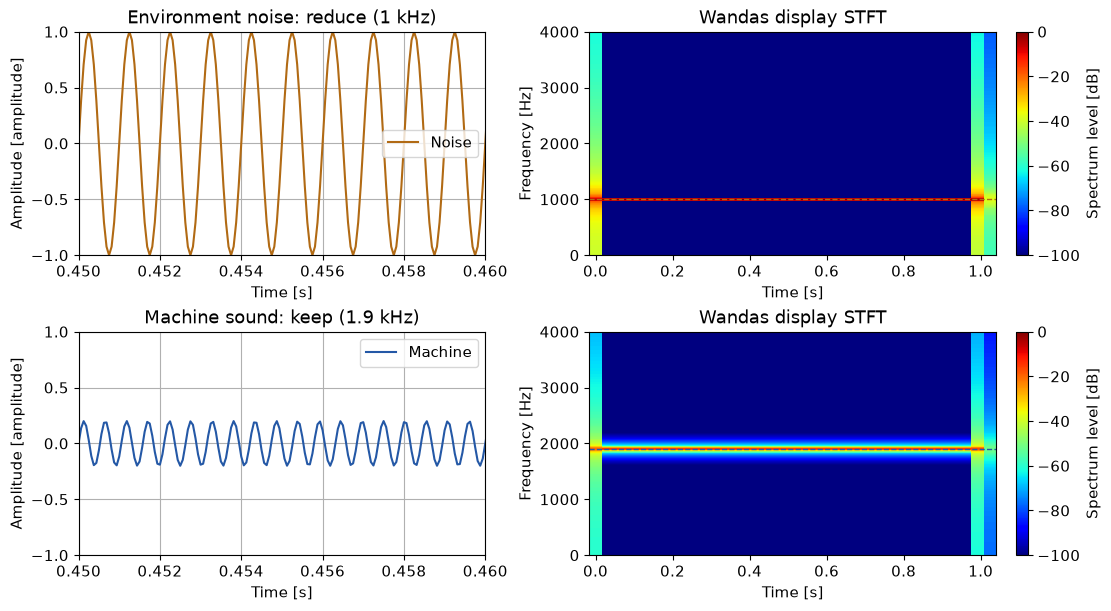

In [5]:
fig = show_sources()
display(fig); plt.close(fig)
if ENABLE_AUDIO:
    for role in ("noise", "machine"):
        show(sources[role], audio=True)

### B0：近いマイク — 機械音と環境ノイズの混合

**見る点：** 1,000 Hzは環境ノイズ、1,900 Hzは機械音です。灰の波形は混合音で、青の破線は残したい機械音です。次の減算後の図では、両方の周波数がどう変わるかを見ます。

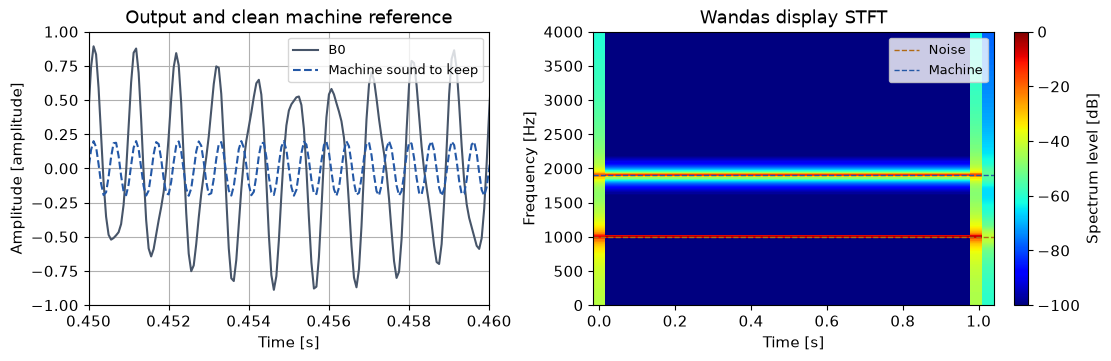

In [6]:
display_demo("b0")

### B1：遠いマイク — こちらにも機械音が入る

**見る点：** 遠方にも1,900 Hzの機械音の横線があります。機械音・環境ノイズとも、近接とは大きさと位相が異なります。この混合音を引き算の手掛かりにします。

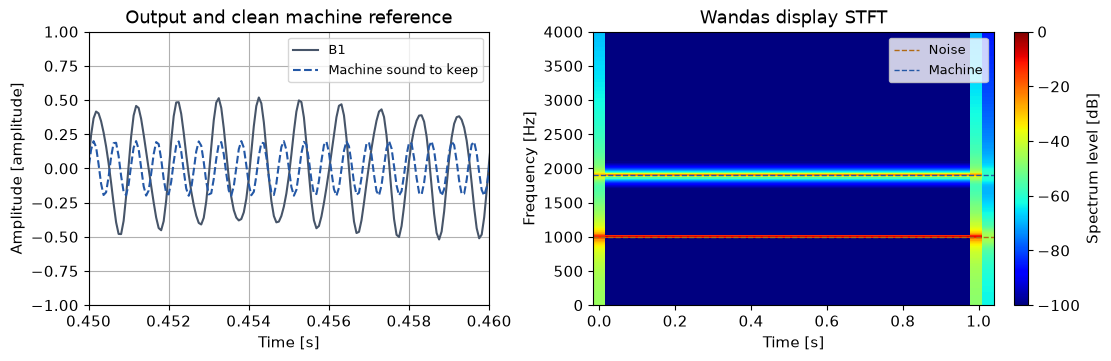

In [7]:
display_demo("b1")

### W1：大きさと位相を合わせて引く

**見る点：** 録音の中央では、1,000 Hzのノイズだけでなく、1,900 Hzの機械音も大きく弱まります。両マイクに共通する機械音も係数推定に入り、減算されるためです。青の破線と比べると、残したい波形も失われています。端には成分が残ります。

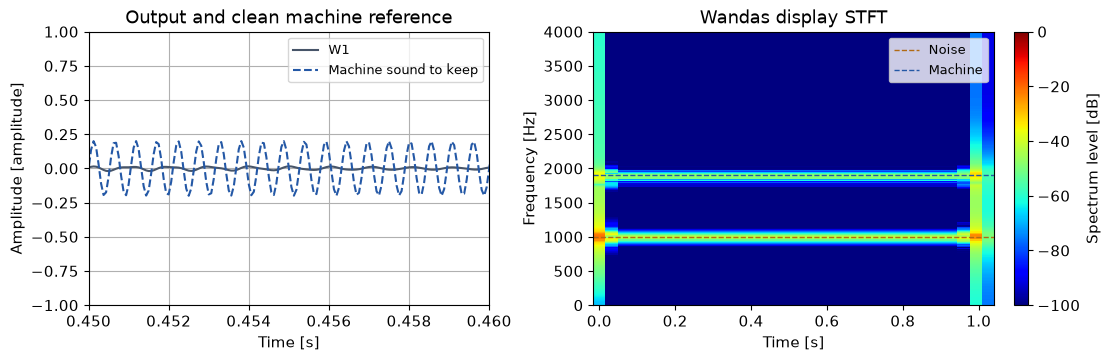

In [8]:
display_demo("w1")

### SS：大きさだけを引く

**見る点：** ノイズ・機械音の横線がともにB0より弱まります。遠方に入った機械音の大きさも引いてしまうためです。近接の位相を使い、大きさだけを引く[Chu・Qian技術報告](https://dcase.community/documents/challenge2026/technical_reports/DCASE2026_Qian_65_t2.pdf)の式1で計算しています。

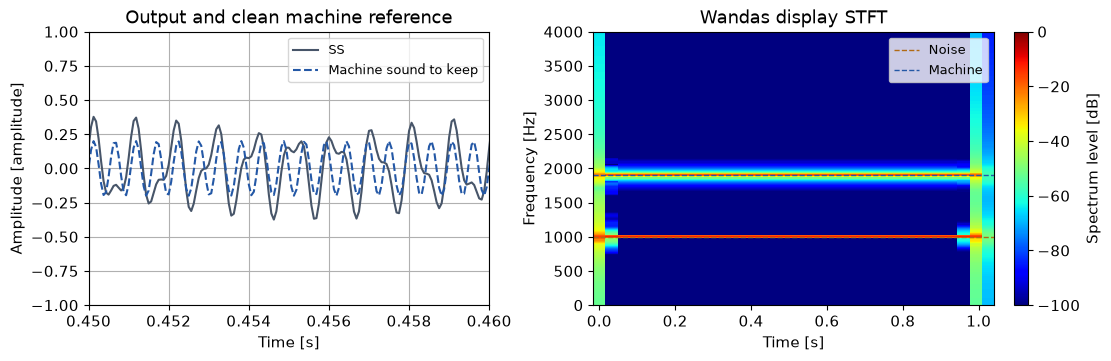

In [9]:
display_demo("ss")

### 合成図と実測

固定の倍率・位相差を持つ2つの定常トーンの例で、反射や経路の時間変化は表していません。この例は、遠方に入る機械音も減算で失われ得ることを示します。実際の機械音を使った異常検知の成績は2節の表です。

波形の計算はCLI共通のTorch関数、表示と手動試聴はWandas 0.8.0を使います。Wandasの表示用STFTと、減算のTorch STFTは設定が異なります。

## 4. 実装を読む

[実装案内](../src/asd_min/README.md) · [固定条件](../docs/02-protocol.md) · [入力取得](../docs/02-inputs.md) · [出典と利用条件](../docs/rights.md)